# Introduction to NetworkX
---

- Library to build and handle graphs (=Networks)
- Summaizes also multiple functions to characterize a given graph
- In general a graph consists of nodes (Agents) and edges (Connections)
- Tutorial: https://networkx.org/documentation/stable/tutorial.html

In [26]:
# Imports
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np

# Number of Nodes/Agents
N_agents = 50

### Graph Generators
- There are tons of different ways to generate various networks of different characteristics
- Overview: https://networkx.org/documentation/stable/reference/generators.html
- We will just focus on three types for now:
    - Erdős-Rényi graph or a binomial graph
    https://networkx.org/documentation/stable/reference/generated/networkx.generators.random_graphs.erdos_renyi_graph.html
    - Watts–Strogatz small-world graph
    https://networkx.org/documentation/stable/reference/generated/networkx.generators.random_graphs.watts_strogatz_graph.html
    - Barabási–Albert Graph (Scale-Free Network)
    https://networkx.org/documentation/stable/reference/generated/networkx.generators.random_graphs.barabasi_albert_graph.html
- For any type of graph we can extract the connection array as 2D numpy array via\
`nx.to_numpy_array(G, dtype=int)`

**Erdős-Rényi Graph $G_{N,p}$**
- Simple random/disorderd graph
- For given set of $N$ nodes each possible edge is created at fixed probability $p$
- For small probabilities $p$ the graph might not be connected
- As we want our graphs to be connected graph (each node can be reached) we might need to check this using the `nx.is_connected(G)` function

In [27]:
p = 0.1
while True:
    G = nx.erdos_renyi_graph(N_agents, p)
    if nx.is_connected(G):
        break
con_matrix = nx.to_numpy_array(G, dtype=int)
con_matrix

array([[0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [1, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

**Plotting Graphs**
- We can draw a graph via `nx.draw(G,pos=pos)`
- The position of each nodes can be defined by various algorithms
https://networkx.org/documentation/stable/reference/drawing.html

Text(0.5, 0.98, 'Erdős-Rényi Graph')

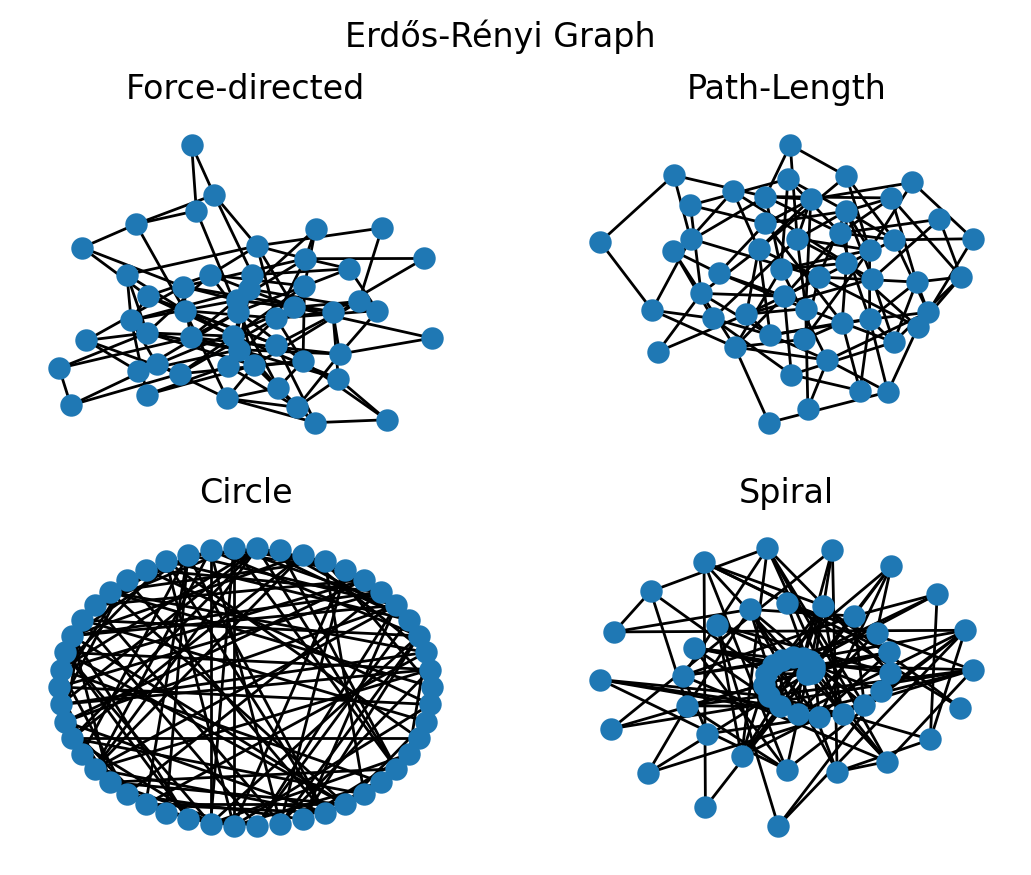

In [28]:
# Different Positions
pos_spring  = nx.spring_layout(G)
pos_kamada  = nx.kamada_kawai_layout(G)
pos_circle  = nx.circular_layout(G)
pos_spiral  = nx.spiral_layout(G)

n_size  = 50
fig     = plt.figure(dpi=200)

ax  = fig.add_subplot(2,2,1)
nx.draw(G, pos=pos_spring, ax=ax, node_size=n_size)
ax.set_title('Force-directed')

ax  = fig.add_subplot(2,2,2)
nx.draw(G, pos=pos_kamada, ax=ax, node_size=n_size)
ax.set_title('Path-Length')

ax  = fig.add_subplot(2,2,3)
nx.draw(G, pos=pos_circle, ax=ax, node_size=n_size)
ax.set_title('Circle')

ax  = fig.add_subplot(2,2,4)
nx.draw(G, pos=pos_spiral, ax=ax, node_size=n_size)
ax.set_title('Spiral')
fig.suptitle("Erdős-Rényi Graph")

**Watts–Strogatz small-world graph $G_{N,k,p}$**
- For given set of $N$ nodes each node is connected to $k$ nearest neighbors
- Given this inital graph each node is also connected to a different node at probability $p$
- For $k=4$ and $p=0$ we get a simple grid
- "Small-world" effect: local structure + global shortcut
- Higher Clustering
- Typical for social networks

In [35]:
p           = 0.1
k           = 4
G           = nx.watts_strogatz_graph(N_agents, k, p)
con_matrix  = nx.to_numpy_array(G, dtype=int)
con_matrix

array([[0, 1, 1, ..., 0, 1, 1],
       [1, 0, 1, ..., 0, 0, 1],
       [1, 1, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 1, 1],
       [1, 0, 0, ..., 1, 0, 1],
       [1, 1, 0, ..., 1, 1, 0]])

Text(0.5, 0.98, 'Watts–Strogatz small-world graph')

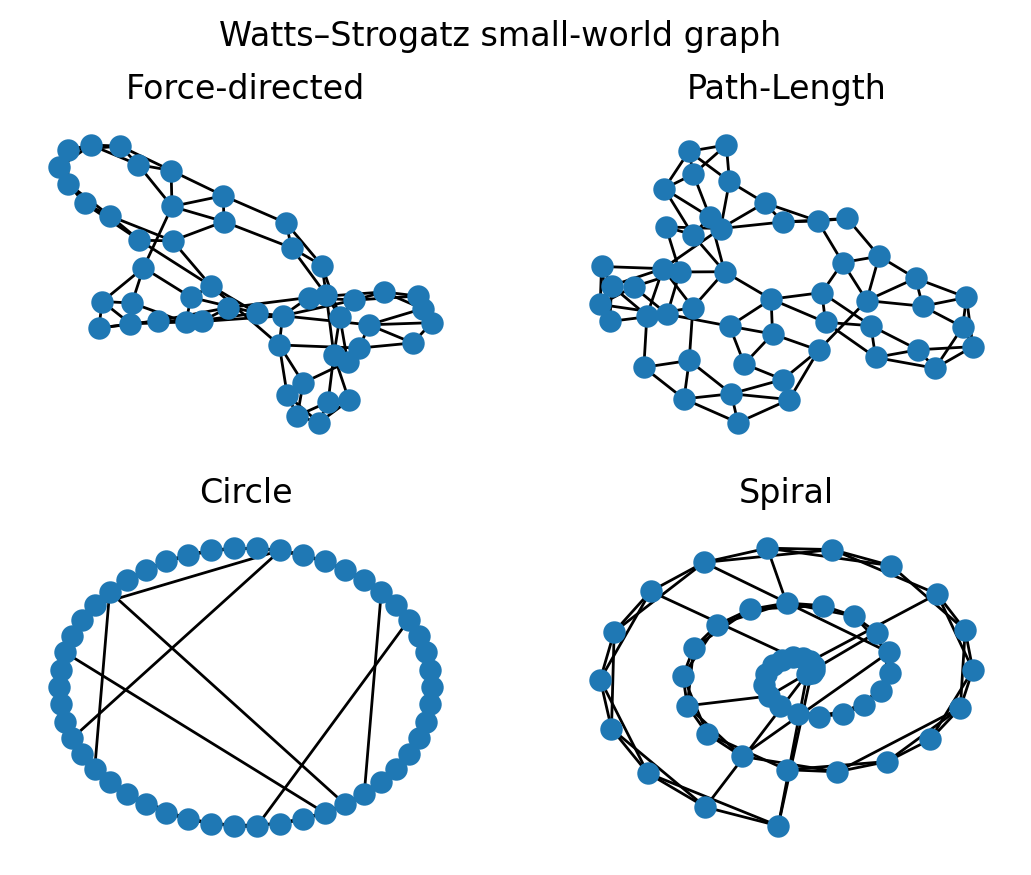

In [36]:
# Different Positions
pos_spring  = nx.spring_layout(G)
pos_kamada  = nx.kamada_kawai_layout(G)
pos_circle  = nx.circular_layout(G)
pos_spiral  = nx.spiral_layout(G)

n_size  = 50
fig     = plt.figure(dpi=200)

ax  = fig.add_subplot(2,2,1)
nx.draw(G, pos=pos_spring, ax=ax, node_size=n_size)
ax.set_title('Force-directed')

ax  = fig.add_subplot(2,2,2)
nx.draw(G, pos=pos_kamada, ax=ax, node_size=n_size)
ax.set_title('Path-Length')

ax  = fig.add_subplot(2,2,3)
nx.draw(G, pos=pos_circle, ax=ax, node_size=n_size)
ax.set_title('Circle')

ax  = fig.add_subplot(2,2,4)
nx.draw(G, pos=pos_spiral, ax=ax, node_size=n_size)
ax.set_title('Spiral')
fig.suptitle("Watts–Strogatz small-world graph")

**Barabási–Albert (Scale-Free) Graph $G_{N,m}$**
- A graph of $N$ fixed nodes is grown by attaching new nodes each with $m$ edges
- Preferential attachment: New nodes are more likely to connect to high-degree (popular) nodes
- Low clustering (unless modified)
- Hub nodes: few nodes with very high degree

In [39]:
m           = 2
G           = nx.barabasi_albert_graph(N_agents, m)
con_matrix  = nx.to_numpy_array(G, dtype=int)
con_matrix

array([[0, 1, 1, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 0],
       [1, 0, 0, ..., 0, 0, 1],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 1, ..., 0, 0, 0]])

Text(0.5, 0.98, 'Barabási–Albert (Scale-Free) Graph')

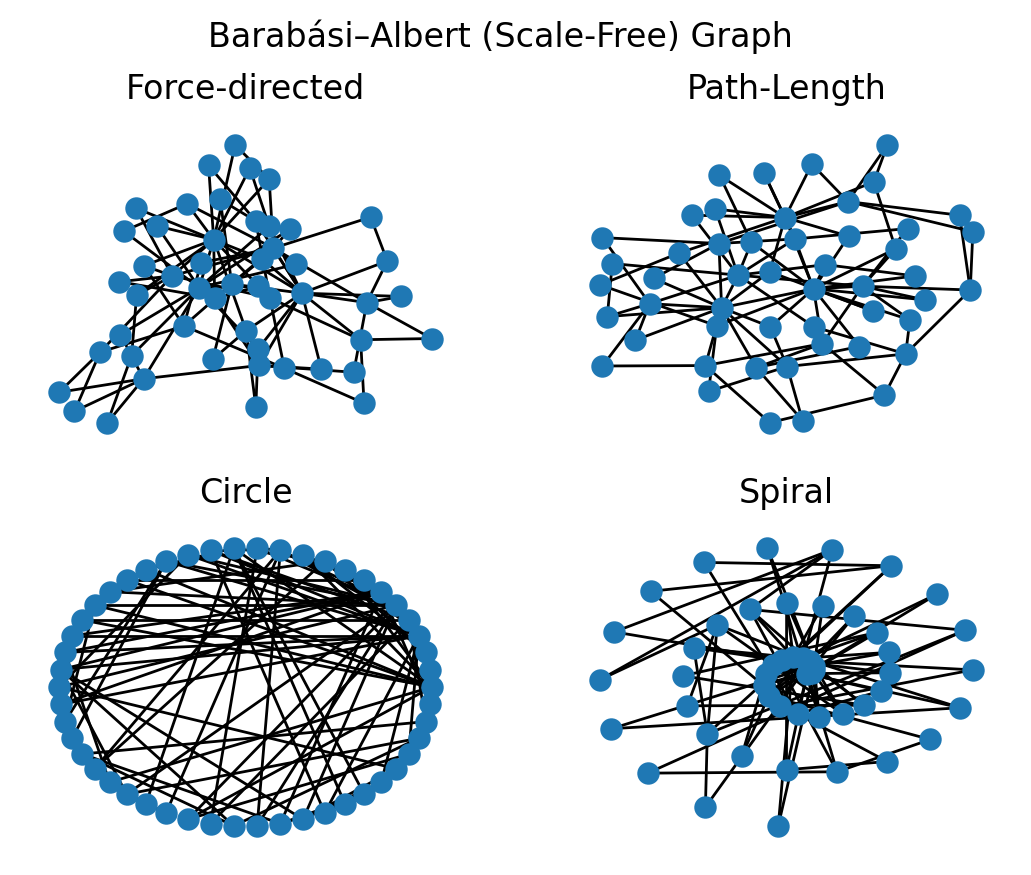

In [41]:
# Different Positions
pos_spring  = nx.spring_layout(G)
pos_kamada  = nx.kamada_kawai_layout(G)
pos_circle  = nx.circular_layout(G)
pos_spiral  = nx.spiral_layout(G)

n_size  = 50
fig     = plt.figure(dpi=200)

ax  = fig.add_subplot(2,2,1)
nx.draw(G, pos=pos_spring, ax=ax, node_size=n_size)
ax.set_title('Force-directed')

ax  = fig.add_subplot(2,2,2)
nx.draw(G, pos=pos_kamada, ax=ax, node_size=n_size)
ax.set_title('Path-Length')

ax  = fig.add_subplot(2,2,3)
nx.draw(G, pos=pos_circle, ax=ax, node_size=n_size)
ax.set_title('Circle')

ax  = fig.add_subplot(2,2,4)
nx.draw(G, pos=pos_spiral, ax=ax, node_size=n_size)
ax.set_title('Spiral')
fig.suptitle("Barabási–Albert (Scale-Free) Graph")